# News Article Categorizer — Checkpoint 1


GROUP MEMBERS NAME

JAGADESH (A24AI0035)

MUHAMMAD SAFRUL ROSLI (A24AI0064)

CHENG  HAO WEN (A24AI0022)


# Import Required Libraries

In [16]:
import os
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

# Dataset Download and Loading (20 Newsgroups)

In [17]:
import kagglehub

path = kagglehub.dataset_download("crawford/20-newsgroups")
print(path)

Using Colab cache for faster access to the '20-newsgroups' dataset.
/kaggle/input/20-newsgroups


# Data Preprocessing and DataFrame Construction

In [18]:
data = []

for file in os.listdir(path):
    if not file.endswith(".txt"):
        continue

    label = file.replace(".txt", "")
    file_path = os.path.join(path, file)

    with open(file_path, encoding="latin1") as f:
        content = f.read()

    articles = content.split("From:")

    for article in articles:
        article = article.strip()

        if len(article.split()) < 20:
            continue

        data.append([article, label])

df = pd.DataFrame(data, columns=["text", "label"])

print(df.shape)
df.head()

(39259, 2)


,text,label
0,kedz@bigwpi.WPI.EDU (John Kedziora)\nSubject: ...,misc.forsale
1,myoakam@cis.ohio-state.edu (micah r yoakam)\nS...,misc.forsale
2,gt1706a@prism.gatech.EDU (Maureen L. Eagle)\nS...,misc.forsale
3,Mike Diack <mike-d@staff.tc.umn.edu>\nSubject:...,misc.forsale
4,jvinson@xsoft.xerox.com (Jeffrey A Vinson)\nSu...,misc.forsale


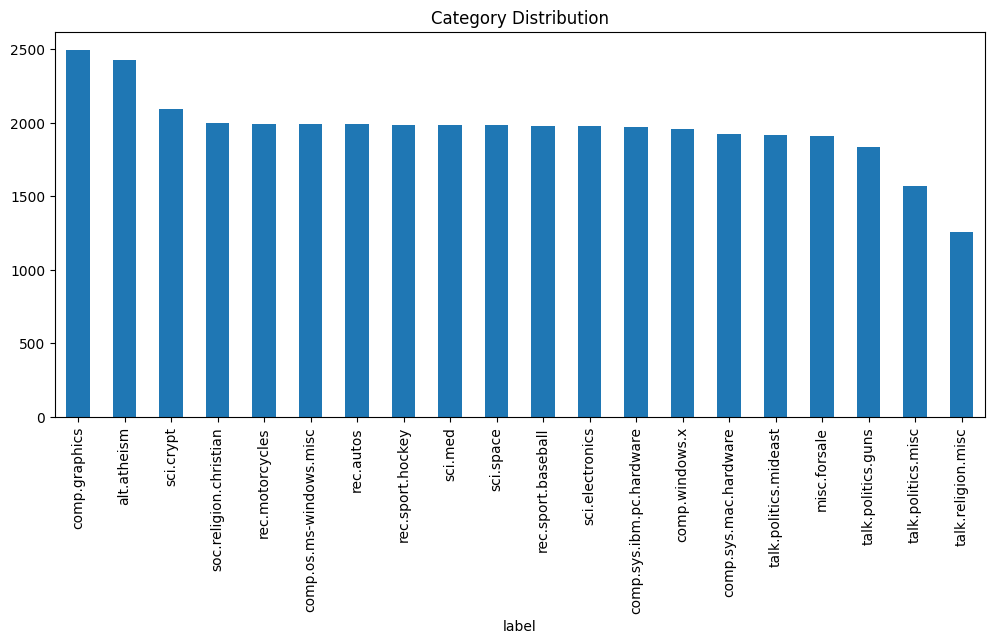

In [19]:
df["label"].value_counts().plot(kind="bar", figsize=(12,5))
plt.title("Category Distribution")
plt.xticks(rotation=90)
plt.show()

# Text Cleaning and NLP Preprocessing

In [20]:
nltk.download("stopwords")
nltk.download("wordnet")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

df["clean_text"] = df["text"].apply(clean_text)

print("Preprocessing done")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Preprocessing done


# Train-Test Split

In [21]:
X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 31407
Test size: 7852


# Feature Extraction Using TF-IDF Vectorization

In [22]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF:", X_train_tfidf.shape)

TF-IDF: (31407, 5000)


# Feature Extraction Using Bag of Words (BoW)

In [23]:
bow = CountVectorizer(max_features=5000)

X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

print("BoW:", X_train_bow.shape)

BoW: (31407, 5000)


# Model Training (Naive Bayes & Logistic Regression - TF-IDF)

In [24]:
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)
pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)

lr_tfidf = LogisticRegression(max_iter=1000)
lr_tfidf.fit(X_train_tfidf, y_train)
pred_lr_tfidf = lr_tfidf.predict(X_test_tfidf)

# Model Training (Naive Bayes & Logistic Regression - BoW)

In [25]:
nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)
pred_nb_bow = nb_bow.predict(X_test_bow)

lr_bow = LogisticRegression(max_iter=1000)
lr_bow.fit(X_train_bow, y_train)
pred_lr_bow = lr_bow.predict(X_test_bow)

# Model Evaluation Results

In [26]:
def evaluate(name, y_true, y_pred):
    print("\n", name)
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print(classification_report(y_true, y_pred))

evaluate("TF-IDF + NB", y_test, pred_nb_tfidf)
evaluate("TF-IDF + LR", y_test, pred_lr_tfidf)
evaluate("BoW + NB", y_test, pred_nb_bow)
evaluate("BoW + LR", y_test, pred_lr_bow)


 TF-IDF + NB
Accuracy: 0.9298267957208355
                          precision    recall  f1-score   support

             alt.atheism       0.87      0.94      0.90       486
           comp.graphics       0.86      0.94      0.90       499
 comp.os.ms-windows.misc       0.92      0.92      0.92       398
comp.sys.ibm.pc.hardware       0.83      0.90      0.86       395
   comp.sys.mac.hardware       0.97      0.93      0.95       385
          comp.windows.x       0.91      0.92      0.92       392
            misc.forsale       0.94      0.90      0.92       382
               rec.autos       0.97      0.96      0.97       398
         rec.motorcycles       0.97      0.98      0.98       399
      rec.sport.baseball       0.98      0.99      0.98       396
        rec.sport.hockey       0.99      0.99      0.99       398
               sci.crypt       0.96      0.96      0.96       418
         sci.electronics       0.95      0.90      0.93       396
                 sci.med       0

# Performance Comparison Table

In [27]:
results = pd.DataFrame({
    "Model": ["TF-IDF + NB", "TF-IDF + LR", "BoW + NB", "BoW + LR"],

    "Accuracy": [
        accuracy_score(y_test, pred_nb_tfidf),
        accuracy_score(y_test, pred_lr_tfidf),
        accuracy_score(y_test, pred_nb_bow),
        accuracy_score(y_test, pred_lr_bow)
    ],

    "Precision": [
        precision_score(y_test, pred_nb_tfidf, average="weighted"),
        precision_score(y_test, pred_lr_tfidf, average="weighted"),
        precision_score(y_test, pred_nb_bow, average="weighted"),
        precision_score(y_test, pred_lr_bow, average="weighted")
    ],

    "Recall": [
        recall_score(y_test, pred_nb_tfidf, average="weighted"),
        recall_score(y_test, pred_lr_tfidf, average="weighted"),
        recall_score(y_test, pred_nb_bow, average="weighted"),
        recall_score(y_test, pred_lr_bow, average="weighted")
    ],

    "F1-Score": [
        f1_score(y_test, pred_nb_tfidf, average="weighted"),
        f1_score(y_test, pred_lr_tfidf, average="weighted"),
        f1_score(y_test, pred_nb_bow, average="weighted"),
        f1_score(y_test, pred_lr_bow, average="weighted")
    ]
})

from IPython.display import display
display(results.round(4))

,Model,Accuracy,Precision,Recall,F1-Score
0,TF-IDF + NB,0.9298,0.9327,0.9298,0.9287
1,TF-IDF + LR,0.9907,0.9908,0.9907,0.9907
2,BoW + NB,0.9386,0.9392,0.9386,0.9384
3,BoW + LR,0.9972,0.9972,0.9972,0.9972


# Confusion Matrix

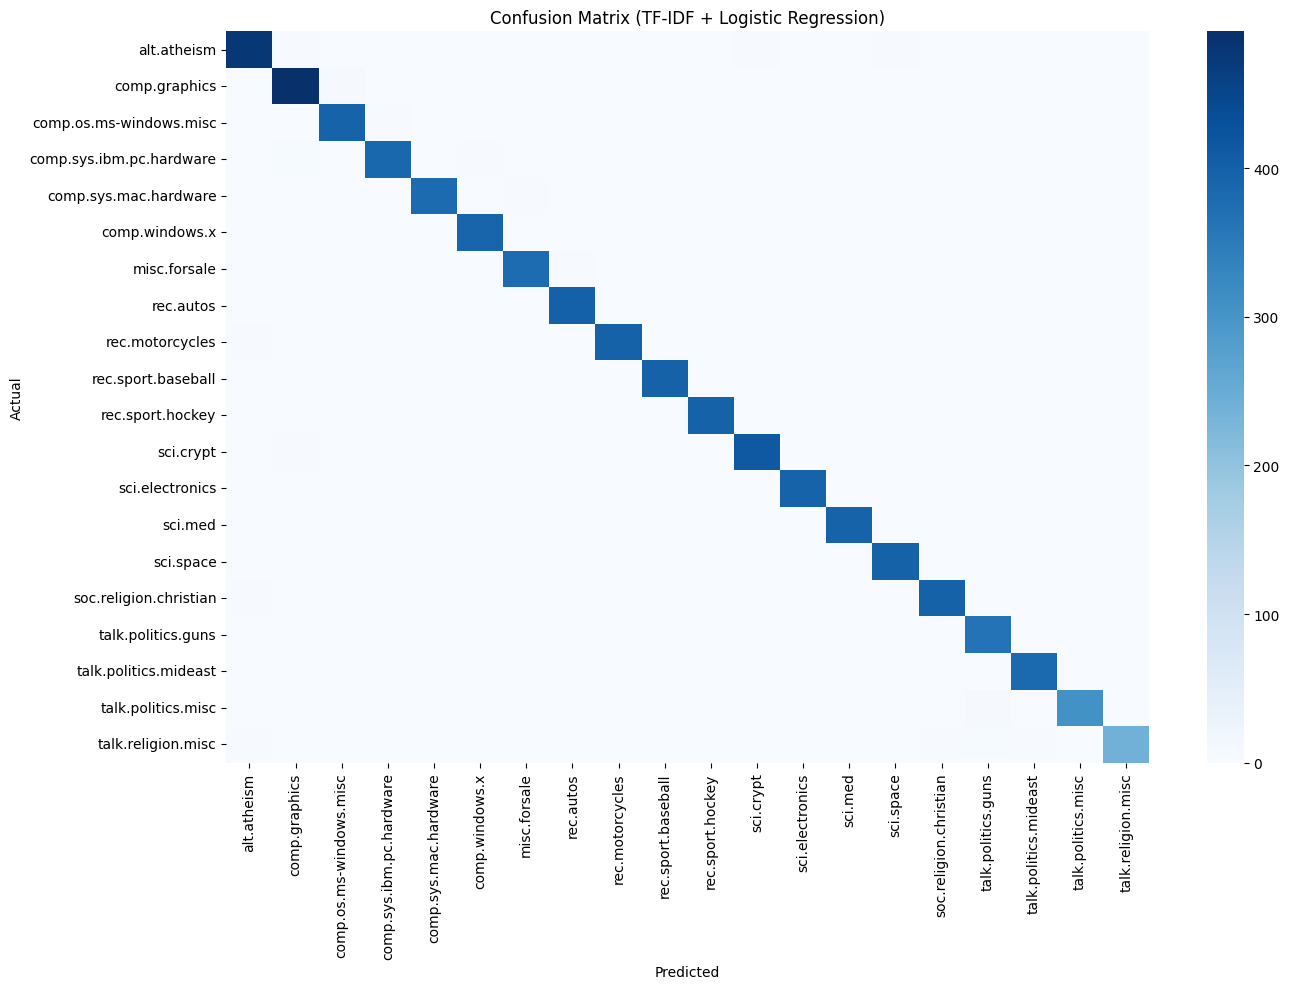

In [28]:
labels = sorted(y.unique())

cm = confusion_matrix(y_test, pred_lr_tfidf, labels=labels)

plt.figure(figsize=(14,10))
sns.heatmap(cm, cmap="Blues", xticklabels=labels, yticklabels=labels, annot=False)

plt.title("Confusion Matrix (TF-IDF + Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# Save Trained Model for Deployment

In [29]:
import joblib

# Save Vectorizers
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
joblib.dump(bow, "bow_vectorizer.pkl")

# Save the Models trained on TF-IDF
joblib.dump(lr_tfidf, "lr_tfidf_model.pkl")
joblib.dump(nb_tfidf, "nb_tfidf_model.pkl")

# Save the Models trained on BoW
joblib.dump(lr_bow, "lr_bow_model.pkl")
joblib.dump(nb_bow, "nb_bow_model.pkl")

print("All 4 models and 2 vectorizers saved successfully!")

All 4 models and 2 vectorizers saved successfully!


In [30]:
import joblib
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# 1. Ensure NLTK resources are available
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

# 2. Recreate your EXACT cleaning function
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

# 3. Load your saved model and vectorizer
# (Make sure "best_model.pkl" and "vectorizer.pkl" are in the same directory)
print("Loading model and vectorizer...")
model = joblib.load("lr_tfidf_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

# 4. Input the test data (Combining Subject and Body)
test_samples = [
    """Subject: Next-generation ion thrusters and iodine propellant efficiency

    Recent breakthroughs in electrostatic ion thruster technology have shown highly promising results for long-duration deep space missions. Engineers are heavily testing iodine-based propellants as a dense, low-cost alternative to traditional xenon gas. Because iodine can be stored as a solid without high-pressure tanks, it drastically reduces the structural mass of the spacecraft.""",

    """Subject: Isolate digital noise on a mixed-signal PCB design

    I am laying out a 4-layer mixed-signal printed circuit board that features a high-speed microcontroller operating alongside a high-precision 24-bit Analog-to-Digital Converter (ADC). During prototyping, I am noticing significant high-frequency switching noise bleeding from the digital clock lines into the analog front-end."""
]

# 5. Run the prediction pipeline
print("\n--- Prediction Results ---")
for raw_text in test_samples:
    # Clean the text
    cleaned = clean_text(raw_text)

    # Vectorize the cleaned text
    # Note: .transform() expects an iterable (like a list), so we put 'cleaned' in brackets
    vectorized_text = vectorizer.transform([cleaned])

    # Predict the category
    prediction = model.predict(vectorized_text)[0]

    # Output the result
    # We grab the first line of the raw text just to display a short title in the output
    snippet = raw_text.split('\n')[0]
    print(f"Article: {snippet}")
    print(f"Predicted Category: {prediction}\n")

Loading model and vectorizer...

--- Prediction Results ---
Article: Subject: Next-generation ion thrusters and iodine propellant efficiency
Predicted Category: sci.space

Article: Subject: Isolate digital noise on a mixed-signal PCB design
Predicted Category: sci.electronics

